In [1]:
from matplotlib import pyplot as plt
import numpy as np

from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

np.random.seed(42)

In [2]:
mnist = fetch_openml("mnist_784")
X, y = mnist["data"].to_numpy().reshape(-1, 28, 28).astype(float), mnist[
    "target"
].to_numpy().astype(int)
X[X <= 127] = 0.0
X[X > 127] = 1.0
n = X.shape[1] * X.shape[2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(X_train.data.shape)
# Shape information
H, W = X_train.shape[1], X_train.shape[2]  # Height and Width

C:\Users\sumuk\AppData\Roaming\Python\Python310\site-packages\sklearn\datasets\_openml.py:932: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


(63000, 28, 28)


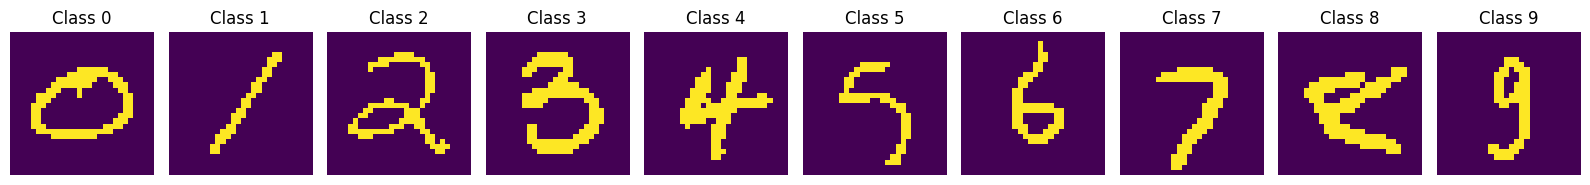

In [3]:
def plot_digits(X_train, y_train, num_classes=10):
    fig, axes = plt.subplots(1,num_classes, figsize=(16, 6))

    for cls in range(num_classes):
        # Select a random image from the class
        class_indices = np.where(y_train == cls)[0]
        random_index = np.random.choice(class_indices)
        random_image = X_train[random_index]

        # Plot the random image
        axes[cls].imshow(random_image)
        axes[cls].set_title(f"Class {cls}")
        axes[cls].axis("off")

    plt.tight_layout()

plot_digits(X_train, y_train)

In [4]:
# Helper function for Laplace smoothing
def laplace_smoothing(count, total, alpha=1, coef=2):
    return (count + alpha) / (total + coef * alpha)

# Naive Bayes Classifier
class NaiveBayesClassifier:
    def __init__(self, num_classes=10):
        self.num_classes = num_classes
        self.P_y = None  # Prior probabilities P(y)
        self.P_xy = None  # Likelihood probabilities P(x|y)

    def train(self, X, y):
        print("Training NaiveBayes...")
        n_samples, H, W = X.shape
        self.P_y = np.zeros(self.num_classes)
        self.P_xy = np.zeros((self.num_classes, H, W))

        # Compute P(y) - Prior probabilities
        for cls in range(self.num_classes):
            self.P_y[cls] = laplace_smoothing(
                np.sum(y == cls),
                n_samples
            )
        
        # Compute P(x|y) - Likelihood probabilities
        for cls in range(self.num_classes):
            class_indices = np.where(y == cls)[0]
            class_images = X[class_indices]
            self.P_xy[cls] = laplace_smoothing(
                np.sum(class_images, axis=0),  # Count of pixel activations for class
                class_images.shape[0]  # Total samples in class
            )
        print("Training complete.")

    def predict(self, X):
        print("Testing NaiveBayes...")
        n_samples, H, W = X.shape
        log_likelihood = np.zeros((n_samples, self.num_classes))
        
        for cls in range(self.num_classes):
            # Compute log-likelihood: P(y) * P(x|y)
            log_prior = np.log(self.P_y[cls])
            log_px_given_y = np.sum(
                X * np.log(self.P_xy[cls]) + (1 - X) * np.log(1 - self.P_xy[cls]),
                axis=(1, 2)
            )
            log_likelihood[:, cls] = log_prior + log_px_given_y

        # Choose the class with the highest log-likelihood
        predictions = np.argmax(log_likelihood, axis=1)
        return predictions

# Instantiate the classifier
nb_classifier = NaiveBayesClassifier(num_classes=10)

# Flatten the images for training and testing
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train the classifier
nb_classifier.train(X_train, y_train)

# Test the classifier
predictions = nb_classifier.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy of Naive Bayes Classifier: {accuracy:.2f}")


Training NaiveBayes...
Training complete.
Testing NaiveBayes...
Accuracy of Naive Bayes Classifier: 0.84


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression Classifier
class LogisticRegressionClassifier:
    def __init__(self, num_classes=10):
        self.num_classes = num_classes
        self.lr_model = LogisticRegression(
            multi_class="multinomial", solver="lbfgs", max_iter=1000
        )  # Initialize logistic regression model

    def train(self, X, y):
        print("Training logistic regression...")
        # Flatten the input data and standardize it
        scaler = StandardScaler()
        X_flat = X.reshape(X.shape[0], -1)
        X_scaled = scaler.fit_transform(X_flat)
        self.lr_model.fit(X_scaled, y)  # Train the logistic regression model
        print("Training complete.")

    def predict(self, X):
        print("Predicting with logistic regression...")
        # Flatten the input data and standardize it
        scaler = StandardScaler()
        X_flat = X.reshape(X.shape[0], -1)
        X_scaled = scaler.fit_transform(X_flat)
        predictions = self.lr_model.predict(X_scaled)  # Predict using the trained model
        return predictions

    def get_weights(self):
        if self.lr_model is None:
            return None
        return self.lr_model.coef_  # For visualization purposes only


# Instantiate and train the Logistic Regression Classifier
lr_classifier = LogisticRegressionClassifier(num_classes=10)

# Train the classifier
lr_classifier.train(X_train, y_train)

# Test the classifier
lr_predictions = lr_classifier.predict(X_test)

# Compute accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Accuracy of Logistic Regression Classifier: {lr_accuracy:.2f}")

# Visualize weights (optional, for debug or interpretation purposes)
weights = lr_classifier.get_weights()
if weights is not None:
    print("Logistic Regression Weights:")
    print(weights)


Training logistic regression...
Training complete.
Predicting with logistic regression...
Accuracy of Logistic Regression Classifier: 0.91
Logistic Regression Weights:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [6]:
# Train and Evaluate Naive Bayes Classifier
nb_classifier = NaiveBayesClassifier()
nb_classifier.train(X_train, y_train)
nb_preds = nb_classifier.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_preds)
print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

# Train and Evaluate Logistic Regression Classifier
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train.reshape(-1, n))
X_test_lr = scaler.transform(X_test.reshape(-1, n))
lr_classifier = LogisticRegressionClassifier()
lr_classifier.train(X_train_lr, y_train)
lr_preds = lr_classifier.predict(X_test_lr)
lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")


Training NaiveBayes...
Training complete.
Testing NaiveBayes...
Naive Bayes Accuracy: 83.59%
Training logistic regression...
Training complete.
Predicting with logistic regression...
Logistic Regression Accuracy: 90.60%


Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...
Testing NaiveBayes...


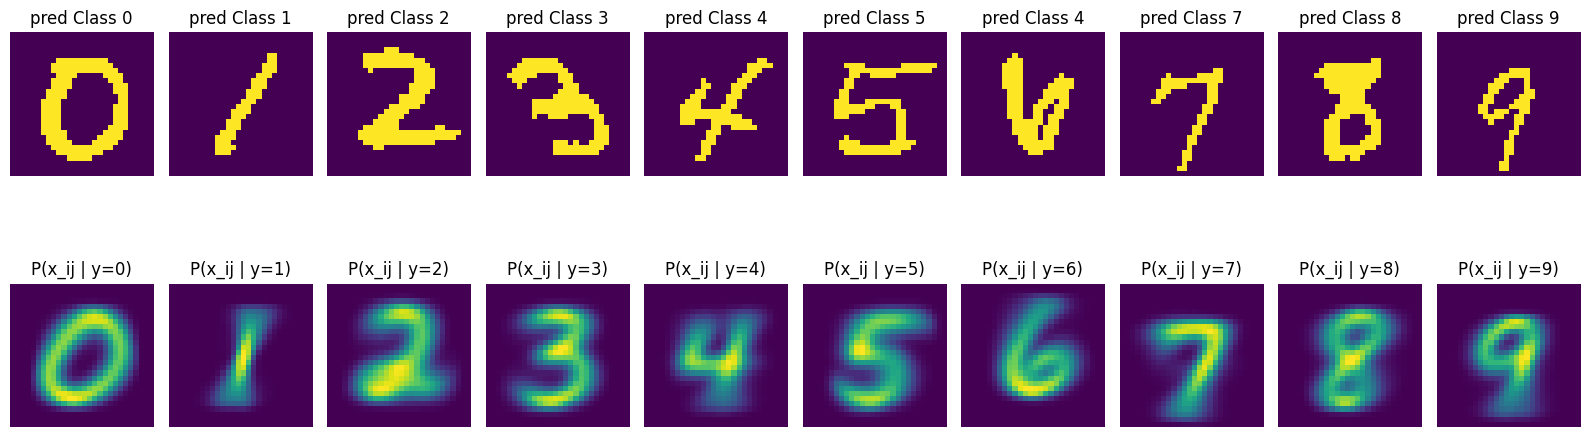

In [7]:
# Function to plot a random image and its corresponding P_xy for each class
def plot_random_image_and_p_xy(nb_classifier, X_test, y_test, num_classes=10):
    fig, axes = plt.subplots(2, num_classes, figsize=(16, 6))

    for cls in range(num_classes):
        # Select a random image from the class
        class_indices = np.where(y_test == cls)[0]
        random_index = np.random.choice(class_indices)
        random_image = X_test[random_index]
        prediction = nb_classifier.predict(random_image.reshape(1, H, W))[0]

        # Plot the random image
        axes[0, cls].imshow(random_image)
        axes[0, cls].set_title(f"pred Class {int(prediction)}")
        axes[0, cls].axis("off")

        # Plot the P_xy for the class
        axes[1, cls].imshow(nb_classifier.P_xy[cls])
        axes[1, cls].set_title(f"P(x_ij | y={cls})")
        axes[1, cls].axis("off")

    plt.tight_layout()

# Example usage
plot_random_image_and_p_xy(nb_classifier, X_train, y_train)

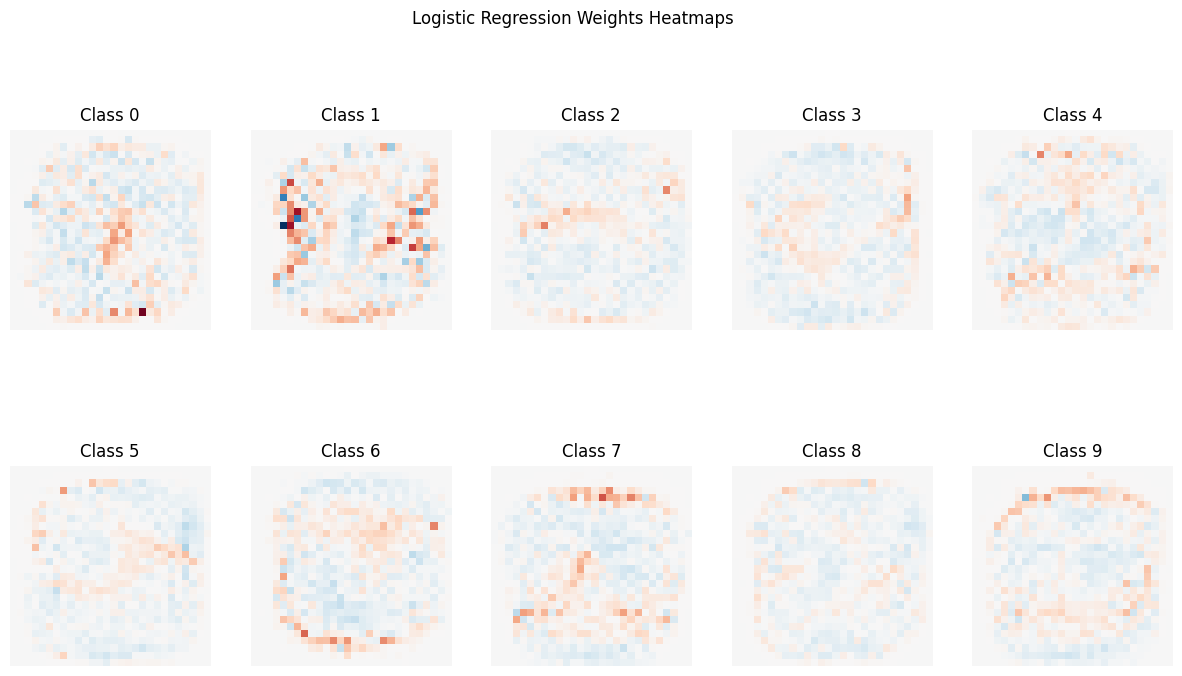

In [8]:
# Visualize weights for each class
coef = lr_classifier.get_weights()
if coef is None:
    print("No weights found")
    coef = np.random.randn(10, 28, 28)
weights = coef.reshape(10, 28, 28)
scale = np.abs(coef).max()

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        weights[i],
        interpolation="nearest",
        cmap=plt.cm.RdBu,
        vmin=-scale,
        vmax=scale,
    )
    plt.title(f"Class {i}")
    plt.axis("off")
plt.suptitle("Logistic Regression Weights Heatmaps")
plt.show()